# STEP 4 · 参数敏感性
在开头选择 `CITY`、`CITY_CONFIG` 和 `MODE`。本 notebook 对当前城市做参数敏感性：换合理参数后基线两口径如何变化

### 各参数含义与预期方向
| 参数 | 含义 | 调大预期 |
|---|---|---|
| `GAMMA` γ | 一个快桩顶几个慢桩(=μ_fast/μ_slow) | 总有效容量↑ → 空间置换 M↓ |
| `SYS_UTIL` u | 系统利用率=总需求/总容量 | 容量越紧 → 空间置换 M↑ |
| `MU_FAST` | 快充服务率 辆/h | 服务能力↑ → 时间排队 M↓ |
| `OPER_HOURS` H | 有效营业时长 | 日需求摊得更平、到达率↓ → 时间排队 M↓ |
| `WAIT_BALK_MIN` | 司机愿排队上限(分钟) | 封顶放宽 → 时间排队 M↑(或抛锚↓) |
| `C_BAR` | 低电量车可达里程 | 低电量时站更多 → 两口径 M↓ |


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'      # 城市配置键；全国城市可改成 'shenzhen' 等
CITY_CONFIG = ''        # 可选：外部 city_configs.json 路径，例如 r'../city_configs.json'
MODE = 'truncated'      # 'truncated' 或 'comprehensive'
NOTEBOOK_SMOKE = False  # True 时减少抽样和候选规模，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
print(f'当前城市：{cso.CITY_NAME} ({cso.CITY}) | 口径：{MODE} | 抽样次数：{DRAWS}')


当前城市：广州 (guangzhou) | 口径：truncated | 抽样次数：40


In [2]:
st = cso.load_stations(MODE)
slon, slat = st['lon'].values, st['lat'].values
fast, slow = st['fast'].values, st['slow'].values
D = cso.demand_surface(draws=DRAWS)
lc, ac, w = D['lon_c'], D['lat_c'], D['w']
c = cso.dist_matrix(lc, ac, slon, slat)
print(f'{cso.CITY_NAME} · {MODE}: 站点 {len(slon)} 个，需求格 {D["n_cells"]} 个，期望低电量事件 {w.sum():.0f} 次/天')


广州 · truncated: 站点 873 个，需求格 3336 个，期望低电量事件 4489 次/天


## 4.1 空间置换：扫 γ、u、C_BAR


In [3]:
rows=[]
for g in [5,8,10,15]: rows.append(dict(参数='γ快慢比',值=g,M_disp_km=round(cso.M_disp(w,c,fast,slow,gamma=g)['M'],0)))
for u in [0.8,1.0,1.2,1.5]: rows.append(dict(参数='u利用率',值=u,M_disp_km=round(cso.M_disp(w,c,fast,slow,u=u)['M'],0)))
cb0=cso.C_BAR
for cb in [60,100,140]:
    cso.C_BAR=cb; rows.append(dict(参数='C_BAR可达里程',值=cb,M_disp_km=round(cso.M_disp(w,c,fast,slow)['M'],0)))
cso.C_BAR=cb0
print(pd.DataFrame(rows).to_string(index=False))


       参数     值  M_disp_km
     γ快慢比   5.0   806751.0
     γ快慢比   8.0   800847.0
     γ快慢比  10.0   798776.0
     γ快慢比  15.0   795937.0
     u利用率   0.8   385469.0
     u利用率   1.0   798776.0
     u利用率   1.2  1148910.0
     u利用率   1.5  1693896.0
C_BAR可达里程  60.0   798776.0
C_BAR可达里程 100.0   798776.0
C_BAR可达里程 140.0   798776.0


## 4.2 时间排队：扫 μ_fast、H、WAIT_BALK_MIN


In [4]:
rows=[]; mf0,h0,b0=cso.MU_FAST,cso.OPER_HOURS,cso.WAIT_BALK_MIN
for mf in [1.5,2.0,2.4]:
    cso.MU_FAST=mf; rows.append(dict(参数='μ_fast服务率',值=mf,M_queue_min=round(cso.M_queue(w,c,fast,slow)['M'],0)))
cso.MU_FAST=mf0
for H in [10,14,18]:
    cso.OPER_HOURS=H; rows.append(dict(参数='H营业时长',值=H,M_queue_min=round(cso.M_queue(w,c,fast,slow)['M'],0)))
cso.OPER_HOURS=h0
for bk in [20,30,45]:
    cso.WAIT_BALK_MIN=bk; rows.append(dict(参数='等待上限min',值=bk,M_queue_min=round(cso.M_queue(w,c,fast,slow)['M'],0)))
cso.WAIT_BALK_MIN=b0
print(pd.DataFrame(rows).to_string(index=False))


       参数    值  M_queue_min
μ_fast服务率  1.5     845680.0
μ_fast服务率  2.0     716578.0
μ_fast服务率  2.4     625738.0
    H营业时长 10.0    1019849.0
    H营业时长 14.0     716578.0
    H营业时长 18.0     526832.0
  等待上限min 20.0     709570.0
  等待上限min 30.0     716578.0
  等待上限min 45.0     726587.0


## 4.3 敏感性测试汇总图

第一行是空间置换口径，第二行是时间排队口径。每个小图只看本参数变化时 M 的方向是否符合预期。


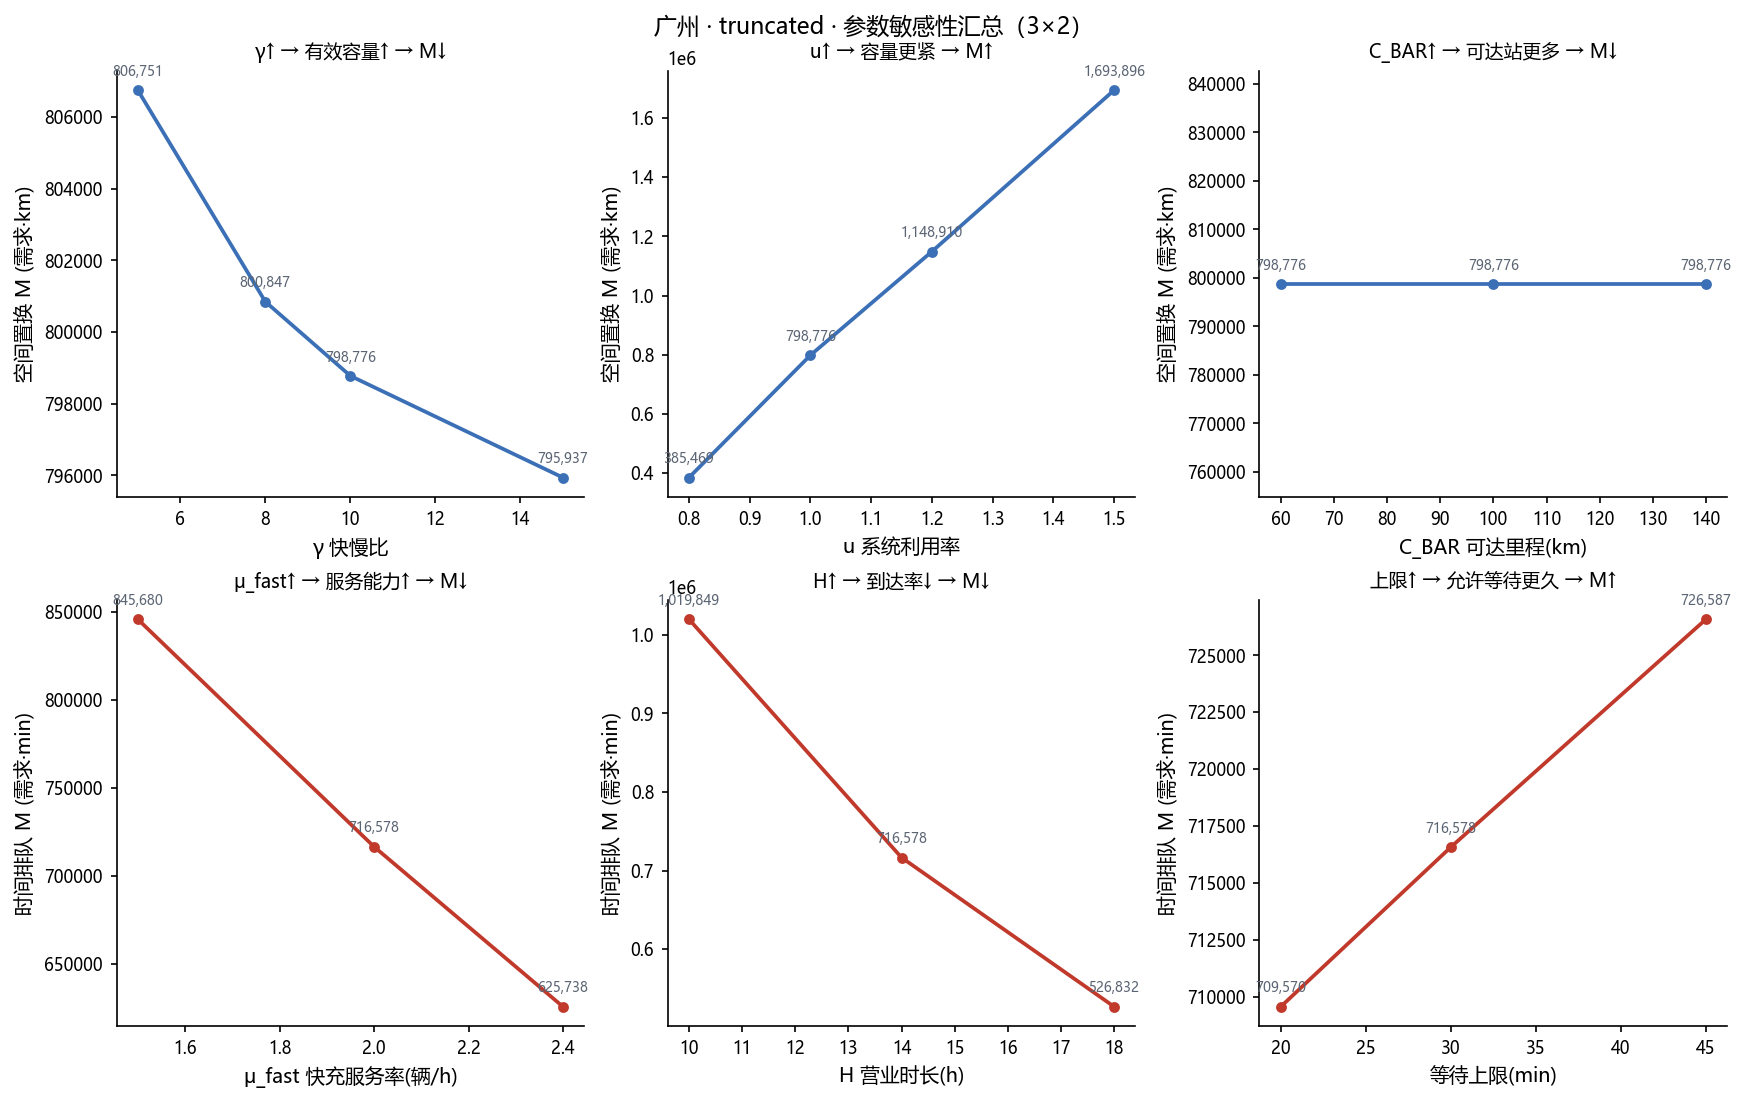

In [5]:
def _restore_params(gamma=None, util=None, cbar=None, mu_fast=None, hours=None, wait=None):
    # 这里只恢复会被临时改写的全局参数，避免一个敏感性测试影响下一个测试。
    if cbar is not None:
        cso.C_BAR = cbar
    if mu_fast is not None:
        cso.MU_FAST = mu_fast
    if hours is not None:
        cso.OPER_HOURS = hours
    if wait is not None:
        cso.WAIT_BALK_MIN = wait

base_cbar, base_mu_fast, base_hours, base_wait = cso.C_BAR, cso.MU_FAST, cso.OPER_HOURS, cso.WAIT_BALK_MIN

# 第一行：空间置换 M_disp。γ 是快慢桩能力比，u 是总需求/总容量的利用率，C_BAR 是低电量车可达里程。
g_vals = [5, 8, 10, 15]
g_m = [cso.M_disp(w, c, fast, slow, gamma=x)['M'] for x in g_vals]
u_vals = [0.8, 1.0, 1.2, 1.5]
u_m = [cso.M_disp(w, c, fast, slow, u=x)['M'] for x in u_vals]
cb_vals = [60, 100, 140]
cb_m = []
for x in cb_vals:
    cso.C_BAR = x
    cb_m.append(cso.M_disp(w, c, fast, slow)['M'])
cso.C_BAR = base_cbar

# 第二行：时间排队 M_queue。μ_fast 是快充服务率，H 是有效营业时长，等待上限是司机愿意排队的分钟数。
mf_vals = [1.5, 2.0, 2.4]
mf_m = []
for x in mf_vals:
    cso.MU_FAST = x
    mf_m.append(cso.M_queue(w, c, fast, slow)['M'])
cso.MU_FAST = base_mu_fast

H_vals = [10, 14, 18]
H_m = []
for x in H_vals:
    cso.OPER_HOURS = x
    H_m.append(cso.M_queue(w, c, fast, slow)['M'])
cso.OPER_HOURS = base_hours

wait_vals = [20, 30, 45]
wait_m = []
for x in wait_vals:
    cso.WAIT_BALK_MIN = x
    wait_m.append(cso.M_queue(w, c, fast, slow)['M'])
cso.WAIT_BALK_MIN = base_wait

fig, ax = plt.subplots(2, 3, figsize=style.mm(183, 112), constrained_layout=True)
panels = [
    (ax[0, 0], g_vals, g_m, 'γ 快慢比', '空间置换 M (需求·km)', 'γ↑ → 有效容量↑ → M↓', style.C['blue']),
    (ax[0, 1], u_vals, u_m, 'u 系统利用率', '空间置换 M (需求·km)', 'u↑ → 容量更紧 → M↑', style.C['blue']),
    (ax[0, 2], cb_vals, cb_m, 'C_BAR 可达里程(km)', '空间置换 M (需求·km)', 'C_BAR↑ → 可达站更多 → M↓', style.C['blue']),
    (ax[1, 0], mf_vals, mf_m, 'μ_fast 快充服务率(辆/h)', '时间排队 M (需求·min)', 'μ_fast↑ → 服务能力↑ → M↓', style.C['red']),
    (ax[1, 1], H_vals, H_m, 'H 营业时长(h)', '时间排队 M (需求·min)', 'H↑ → 到达率↓ → M↓', style.C['red']),
    (ax[1, 2], wait_vals, wait_m, '等待上限(min)', '时间排队 M (需求·min)', '上限↑ → 允许等待更久 → M↑', style.C['red']),
]

for a, xs, ys, xlabel, ylabel, title, col in panels:
    a.plot(xs, ys, '-o', color=col, lw=1.8, ms=4.2)
    a.set_xlabel(xlabel)
    a.set_ylabel(ylabel)
    a.set_title(title, fontsize=9)
    for x, y in zip(xs, ys):
        a.annotate(f'{y:,.0f}', (x, y), textcoords='offset points', xytext=(0, 5),
                   ha='center', va='bottom', fontsize=6.5, color=style.C['gray'])

fig.suptitle(f'{cso.CITY_NAME} · {MODE} · 参数敏感性汇总（3×2）', y=1.02, fontsize=11)
plt.show()

_restore_params(cbar=base_cbar, mu_fast=base_mu_fast, hours=base_hours, wait=base_wait)

